In [1]:
#1 — Imports & paths
from pathlib import Path
import pandas as pd

ROOT = Path('/data0/b2ai-voice/2.0.0')
SPEC = ROOT / 'spectrogram.parquet'
PHEN = ROOT / 'phenotype.tsv'
print(SPEC.exists(), PHEN.exists())


True True


In [2]:
#2 — Load files (safe row-group read)
import pyarrow.parquet as pq

pheno = pd.read_csv(PHEN, sep='\t')

pf = pq.ParquetFile(SPEC)
parts = []
for i in range(pf.num_row_groups):
    parts.append(pf.read_row_group(i, columns=['participant_id','session_id','task_name','spectrogram']).to_pandas())
spec = pd.concat(parts, ignore_index=True)

print("pheno:", pheno.shape, "spec:", spec.shape)
spec.head(2)


pheno: (442, 1109) spec: (16738, 4)


,participant_id,session_id,task_name,spectrogram
0,004d42e9,07031CC3,Animal-fluency,"[[3.2496545, 0.8633412, 0.29140452, -15.261607..."
1,004d42e9,07031CC3,Cinderella-Story,"[[25.801548, 24.044765, 21.460907, 19.336544, ..."


In [3]:
#3 — Build PD label

# Maps “Checked/Unchecked” → 1/0.
pheno['parkinsons_label'] = pheno['parkinsons'].map({'Checked':1, 'Unchecked':0})
labels = pheno[['participant_id','parkinsons_label']].dropna()
labels['parkinsons_label'] = labels['parkinsons_label'].astype(int)
labels['parkinsons_label'].value_counts()


parkinsons_label
0    381
1     61
Name: count, dtype: int64

In [4]:
#4 — Merge

# Joins spectrograms with labels by participant_id.
data = spec.merge(labels, on='participant_id', how='inner')
print("merged:", data.shape)
data[['participant_id','session_id','task_name','parkinsons_label']].head(3)


merged: (16738, 5)


,participant_id,session_id,task_name,parkinsons_label
0,004d42e9,07031CC3,Animal-fluency,0
1,004d42e9,07031CC3,Cinderella-Story,0
2,004d42e9,07031CC3,Diadochokinesis-KA,0


In [6]:
#5 — Inspect spectrogram structure (fixed)
import numpy as np

# We now know: 201 frequency bins × 3002 time frames (but stored as object array)
# Let's properly stack one sample and verify

sample = data['spectrogram'].iloc[0]
arr = np.stack(sample)  # Stack the 201 arrays into a proper 2D array
print(f"Single spectrogram shape: {arr.shape}")
print(f"Dtype: {arr.dtype}, Min: {arr.min():.2f}, Max: {arr.max():.2f}")

# Check a few more to confirm consistency
print("\n--- Checking 5 samples ---")
for i in range(5):
    s = data['spectrogram'].iloc[i]
    stacked = np.stack(s)
    print(f"Sample {i}: shape={stacked.shape}")

# Check shape distribution across all data
print("\n--- Shape distribution across dataset ---")
shapes = data['spectrogram'].apply(lambda x: (len(x), len(x[0])))
print(f"Unique shapes: {shapes.nunique()}")
print(shapes.value_counts().head(10))

Single spectrogram shape: (201, 3002)
Dtype: float32, Min: -33.99, Max: 46.01

--- Checking 5 samples ---
Sample 0: shape=(201, 3002)
Sample 1: shape=(201, 12225)
Sample 2: shape=(201, 214)
Sample 3: shape=(201, 197)
Sample 4: shape=(201, 434)

--- Shape distribution across dataset ---
Unique shapes: 2586
spectrogram
(201, 1502)    1274
(201, 607)      321
(201, 3002)     243
(201, 1501)     235
(201, 606)       69
(201, 3001)      40
(201, 255)       39
(201, 218)       39
(201, 187)       38
(201, 196)       38
Name: count, dtype: int64


Time dimension statistics:
  Min: 6
  Max: 16628
  Mean: 934.5
  Median: 597.0
  Std: 1087.7

Percentiles:
  25th: 297
  50th: 597
  75th: 1304
  90th: 1697
  95th: 3002
  99th: 4901


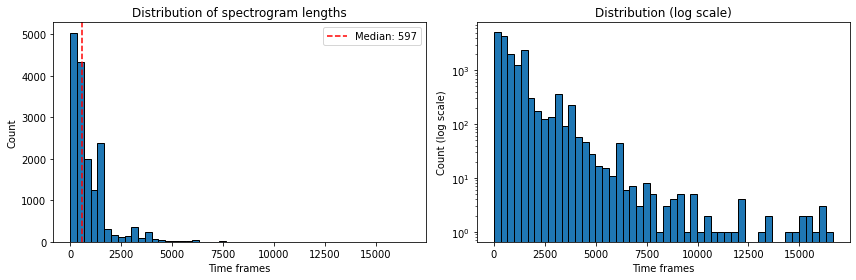


Total samples: 16738


In [7]:
#6 — Analyze time dimension distribution
import numpy as np
import matplotlib.pyplot as plt

# Extract time dimensions
time_dims = data['spectrogram'].apply(lambda x: len(x[0]))

print("Time dimension statistics:")
print(f"  Min: {time_dims.min()}")
print(f"  Max: {time_dims.max()}")
print(f"  Mean: {time_dims.mean():.1f}")
print(f"  Median: {time_dims.median():.1f}")
print(f"  Std: {time_dims.std():.1f}")

# Percentiles to guide truncation/padding decision
percentiles = [25, 50, 75, 90, 95, 99]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p}th: {np.percentile(time_dims, p):.0f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(time_dims, bins=50, edgecolor='black')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of spectrogram lengths')
axes[0].axvline(time_dims.median(), color='r', linestyle='--', label=f'Median: {time_dims.median():.0f}')
axes[0].legend()

# Log scale for better visualization of spread
axes[1].hist(time_dims, bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Time frames')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution (log scale)')

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

print(f"\nTotal samples: {len(time_dims)}")

In [8]:
#7 — Investigate short recordings and length vs label relationship
import numpy as np

# Add time dimension to dataframe for analysis
data['time_frames'] = data['spectrogram'].apply(lambda x: len(x[0]))

# Check very short recordings
short_threshold = 100
short_recordings = data[data['time_frames'] < short_threshold]
print(f"Recordings with < {short_threshold} frames: {len(short_recordings)}")
print(f"Their task distribution:\n{short_recordings['task_name'].value_counts()}")
print(f"Their PD label distribution:\n{short_recordings['parkinsons_label'].value_counts()}")

# Check if length correlates with PD status (potential bias)
print("\n--- Time frames by PD status ---")
for label in [0, 1]:
    subset = data[data['parkinsons_label'] == label]['time_frames']
    print(f"PD={label}: mean={subset.mean():.1f}, median={subset.median():.1f}, n={len(subset)}")

# Check task distribution overall
print("\n--- Task distribution ---")
print(data['task_name'].value_counts())

# Check task distribution by PD status
print("\n--- Tasks by PD status ---")
print(pd.crosstab(data['task_name'], data['parkinsons_label']))

Recordings with < 100 frames: 184
Their task distribution:
task_name
Respiration-and-cough-Breath-2               20
Respiration-and-cough-Cough-2                20
Respiration-and-cough-FiveBreaths-3          20
Respiration-and-cough-FiveBreaths-4          20
Respiration-and-cough-ThreeQuickBreaths-2    19
Free-speech-2                                12
Free-speech-3                                 8
Story-recall                                  8
Cape-V-sentences-2                            6
Cinderella-Story                              6
Free-speech-1                                 5
Cape-V-sentences-3                            4
Respiration-and-cough-Cough-1                 3
Cape-V-sentences-4                            3
Diadochokinesis-KA                            3
Diadochokinesis-TA                            3
Rainbow-Passage                               3
Loudness                                      2
Respiration-and-cough-Breath-1                2
Cape-V-sentences-6 

Short recordings (<100 frames): Mostly respiration/breath tasks, these are intentionally short (breaths, coughs). Not data quality issues, just naturally short tasks.
Length by PD status: Slight difference (PD=1 has mean 1062 vs PD=0 has 904), but medians are similar (607 vs 592). Not a major concern for bias.

Critical finding, Task imbalance by PD status:

Some tasks have almost NO PD patients: Cape-V-sentences (218 vs 1), Caterpillar-Passage (218 vs 1), Free-Speech (167 vs 0)
Some tasks have MORE PD than non-PD: Cinderella-Story (66 vs 85), Word-color-Stroop (67 vs 84)
Balanced tasks: Diadochokinesis-*, Rainbow-Passage, Prolonged-vowel, etc. (~395 vs ~86)


This is important: If we train on all tasks together, the model might learn task-specific patterns rather than PD-specific voice biomarkers. The imbalanced task distribution could confound results.

In [9]:
#8 — Experiment cohorts + preprocess + participant split

import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split


print("CELL #8 (REVISED): Cohort ablations + fixed-length preprocessing + participant split")


# 0) Choose which experiment to run (change this string only)

EXPERIMENT = "A_high_pd_ge100"  
# Options:
# "A_high_pd_ge100"        -> our current baseline (high-PD tasks + >=100 frames)
# "B_high_pd_all_lengths"  -> same high-PD tasks, but include short recordings
# "C_all_tasks_ge100"      -> all tasks, keep >=100 frames
# "D_all_tasks_all_lengths"-> all tasks, include short recordings
# "E_matched_balanced_high_pd_ge100" -> balanced PD/non-PD participants (high-PD tasks + >=100)

RANDOM_STATE = 42
TARGET_SEQ_LEN = 1024  # fixed length for all experiments

# 1) Define task sets

high_pd_only_tasks = [
    'Cinderella-Story',
    'Productive-Vocabulary-1',
    'Productive-Vocabulary-2',
    'Productive-Vocabulary-3',
    'Productive-Vocabulary-4',
    'Productive-Vocabulary-5',
    'Productive-Vocabulary-6',
    'Word-color-Stroop',
    'Random-Item-Generation',
]

all_tasks = sorted(data['task_name'].dropna().unique().tolist())

# 2) Experiment configuration

CONFIGS = {
    "A_high_pd_ge100": dict(task_list=high_pd_only_tasks, min_time_frames=100, matched=False),
    "B_high_pd_all_lengths": dict(task_list=high_pd_only_tasks, min_time_frames=0, matched=False),
    "C_all_tasks_ge100": dict(task_list=all_tasks, min_time_frames=100, matched=False),
    "D_all_tasks_all_lengths": dict(task_list=all_tasks, min_time_frames=0, matched=False),
    "E_matched_balanced_high_pd_ge100": dict(task_list=high_pd_only_tasks, min_time_frames=100, matched=True),
}

assert EXPERIMENT in CONFIGS, f"Unknown EXPERIMENT: {EXPERIMENT}"
cfg = CONFIGS[EXPERIMENT]

print(f"\nRunning EXPERIMENT = {EXPERIMENT}")
print(f"Tasks included: {len(cfg['task_list'])}")
print(f"Min time frames: {cfg['min_time_frames']}")
print(f"Participant matching (balanced PD/non-PD): {cfg['matched']}")


# 3) Filter to cohort
data_exp = data[data['task_name'].isin(cfg['task_list'])].copy()

if cfg['min_time_frames'] > 0:
    data_exp = data_exp[data_exp['time_frames'] >= cfg['min_time_frames']].copy()

# Optional: matched participant cohort (equal PD and non-PD participants)
if cfg['matched']:
    parts = data_exp[['participant_id', 'parkinsons_label']].drop_duplicates()
    pd_parts = parts[parts['parkinsons_label'] == 1]['participant_id'].values
    nonpd_parts = parts[parts['parkinsons_label'] == 0]['participant_id'].values
    
    n = min(len(pd_parts), len(nonpd_parts))
    rng = np.random.RandomState(RANDOM_STATE)
    pd_keep = rng.choice(pd_parts, size=n, replace=False)
    nonpd_keep = rng.choice(nonpd_parts, size=n, replace=False)
    keep_parts = np.concatenate([pd_keep, nonpd_keep])
    
    data_exp = data_exp[data_exp['participant_id'].isin(keep_parts)].copy()

# Report cohort composition
n_samples = len(data_exp)
n_pd_samples = int(data_exp['parkinsons_label'].sum())
n_nonpd_samples = int((data_exp['parkinsons_label'] == 0).sum())
pd_ratio = float(data_exp['parkinsons_label'].mean()) if n_samples else np.nan

n_parts = data_exp['participant_id'].nunique()
n_pd_parts = data_exp.loc[data_exp['parkinsons_label'] == 1, 'participant_id'].nunique()
n_nonpd_parts = data_exp.loc[data_exp['parkinsons_label'] == 0, 'participant_id'].nunique()

print("\n--- Cohort summary ---")
print(f"Samples: {n_samples} | PD: {n_pd_samples} | Non-PD: {n_nonpd_samples} | PD ratio: {pd_ratio:.2%}")
print(f"Participants: {n_parts} | PD: {n_pd_parts} | Non-PD: {n_nonpd_parts}")

print("\nTop tasks by sample count:")
print(data_exp['task_name'].value_counts().head(15))

# 4) Preprocess raw spectrograms: pad/crop to TARGET_SEQ_LEN

def process_spectrogram_raw(spec_raw, target_len=1024):
    spec = np.stack(spec_raw).astype(np.float32)
    n_mels, time_len = spec.shape
    
    if time_len < target_len:
        pad_width = target_len - time_len
        spec = np.pad(spec, ((0, 0), (0, pad_width)), mode='reflect')
    elif time_len > target_len:
        start = (time_len - target_len) // 2
        spec = spec[:, start:start + target_len]
    return spec

print(f"\nPreprocessing spectrograms → fixed shape (201, {TARGET_SEQ_LEN}) ...")

X_list = []
for _, row in tqdm(data_exp.iterrows(), total=len(data_exp), desc="Processing"):
    X_list.append(process_spectrogram_raw(row['spectrogram'], TARGET_SEQ_LEN))

X_raw = np.stack(X_list) if len(X_list) else np.empty((0, 201, TARGET_SEQ_LEN), dtype=np.float32)
y_raw = data_exp['parkinsons_label'].values.astype(int)
participants_raw = data_exp['participant_id'].values

print(f"\nProcessed X_raw: {X_raw.shape} | y_raw: {y_raw.shape}")
if len(X_raw) > 0:
    print(f"Value range: [{X_raw.min():.2f}, {X_raw.max():.2f}]")


# 5) Participant-level train/test split

unique_parts = np.unique(participants_raw)
part_labels = np.array([y_raw[participants_raw == p][0] for p in unique_parts])

print(f"\n--- Participant split stats ---")
print(f"Unique participants: {len(unique_parts)} | PD: {part_labels.sum()} | Non-PD: {(part_labels==0).sum()}")

train_parts, test_parts = train_test_split(
    unique_parts, test_size=0.2, stratify=part_labels, random_state=RANDOM_STATE
)

train_mask = np.isin(participants_raw, train_parts)
test_mask = np.isin(participants_raw, test_parts)

X_train = X_raw[train_mask]
y_train = y_raw[train_mask]
parts_train = participants_raw[train_mask]

X_test = X_raw[test_mask]
y_test = y_raw[test_mask]
parts_test = participants_raw[test_mask]

print(f"\nTrain: {len(X_train)} samples from {len(train_parts)} participants | PD%={y_train.mean():.1%}")
print(f"Test:  {len(X_test)} samples from {len(test_parts)} participants | PD%={y_test.mean():.1%}")

assert len(set(train_parts) & set(test_parts)) == 0, "Leakage: participant overlap detected!"
print(" No participant overlap (leakage check passed)")


CELL #8 (REVISED): Cohort ablations + fixed-length preprocessing + participant split

Running EXPERIMENT = A_high_pd_ge100
Tasks included: 9
Min time frames: 100
Participant matching (balanced PD/non-PD): False

--- Cohort summary ---
Samples: 1349 | PD: 757 | Non-PD: 592 | PD ratio: 56.12%
Participants: 112 | PD: 59 | Non-PD: 53

Top tasks by sample count:
task_name
Productive-Vocabulary-4    151
Word-color-Stroop          151
Productive-Vocabulary-3    151
Productive-Vocabulary-5    151
Productive-Vocabulary-1    150
Productive-Vocabulary-6    150
Productive-Vocabulary-2    150
Random-Item-Generation     150
Cinderella-Story           145
Name: count, dtype: int64

Preprocessing spectrograms → fixed shape (201, 1024) ...


Processing: 100%|██████████| 1349/1349 [00:01<00:00, 905.42it/s]



Processed X_raw: (1349, 201, 1024) | y_raw: (1349,)
Value range: [-100.00, 46.02]

--- Participant split stats ---
Unique participants: 112 | PD: 59 | Non-PD: 53

Train: 1133 samples from 89 participants | PD%=56.5%
Test:  216 samples from 23 participants | PD%=54.2%
 No participant overlap (leakage check passed)


In [11]:
#8c
import numpy as np
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
MIN_FRAMES = 100

data_exp = data[data['time_frames'] >= MIN_FRAMES].copy()

print("EXPERIMENT: C_all_tasks_ge100 (lite)")
print("Min frames:", MIN_FRAMES)

print("\nCohort summary")
print("Samples:", len(data_exp))
print("PD:", int(data_exp['parkinsons_label'].sum()))
print("Non-PD:", int((data_exp['parkinsons_label'] == 0).sum()))
print("PD ratio:", f"{data_exp['parkinsons_label'].mean():.2%}")

print("\nParticipants")
parts = data_exp[['participant_id', 'parkinsons_label']].drop_duplicates()
print("Total:", parts['participant_id'].nunique())
print("PD:", int(parts['parkinsons_label'].sum()))
print("Non-PD:", int((parts['parkinsons_label'] == 0).sum()))

print("\nTop tasks by sample count")
print(data_exp['task_name'].value_counts().head(20))

unique_parts = parts['participant_id'].values
part_labels = parts['parkinsons_label'].values.astype(int)

train_parts, test_parts = train_test_split(
    unique_parts, test_size=0.2, stratify=part_labels, random_state=RANDOM_STATE
)

print("\nSplit")
print("Train participants:", len(train_parts), "| PD:", int(parts[parts['participant_id'].isin(train_parts)]['parkinsons_label'].sum()))
print("Test participants:", len(test_parts), "| PD:", int(parts[parts['participant_id'].isin(test_parts)]['parkinsons_label'].sum()))
print("No overlap:", len(set(train_parts) & set(test_parts)) == 0)


EXPERIMENT: C_all_tasks_ge100 (lite)
Min frames: 100

Cohort summary
Samples: 16554
PD: 3126
Non-PD: 13428
PD ratio: 18.88%

Participants
Total: 442
PD: 61
Non-PD: 381

Top tasks by sample count
task_name
Glides-Low-to-High                           482
Prolonged-vowel                              482
Maximum-phonation-time-1                     481
Glides-High-to-Low                           481
Diadochokinesis-Pataka                       481
Diadochokinesis-buttercup                    481
Diadochokinesis-PA                           480
Maximum-phonation-time-3                     480
Maximum-phonation-time-2                     480
Loudness                                     479
Diadochokinesis-TA                           478
Rainbow-Passage                              478
Diadochokinesis-KA                           478
Respiration-and-cough-FiveBreaths-2          478
Respiration-and-cough-FiveBreaths-1          478
Respiration-and-cough-Breath-1               476
Picture-des

In [12]:
# Dataset with on-the-fly preprocessing (for 8C)
import torch
import numpy as np

TARGET_LEN = 1024

def process_spec(spec_raw, target_len=TARGET_LEN):
    spec = np.stack(spec_raw).astype(np.float32)
    t = spec.shape[1]

    if t < target_len:
        pad = target_len - t
        spec = np.pad(spec, ((0, 0), (0, pad)), mode='reflect')
    elif t > target_len:
        start = (t - target_len) // 2
        spec = spec[:, start:start + target_len]

    return spec


class VoiceDataset(torch.utils.data.Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = process_spec(row['spectrogram'])

        if self.augment:
            if np.random.rand() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, TARGET_LEN - t)
                x[:, t0:t0+t] = 0

        return {
            'inputs': torch.tensor(x, dtype=torch.float32),
            'label': torch.tensor(row['parkinsons_label'], dtype=torch.long),
            'participant': row['participant_id']
        }


In [14]:
#9 — Build train/test DataFrames for 8C using participant split

train_df = data_exp[data_exp['participant_id'].isin(train_parts)].copy()
test_df  = data_exp[data_exp['participant_id'].isin(test_parts)].copy()

print("Train recordings:", len(train_df), "Test recordings:", len(test_df))
print("Train participants:", train_df['participant_id'].nunique(), "Test participants:", test_df['participant_id'].nunique())
print("Participant overlap:", len(set(train_df['participant_id']) & set(test_df['participant_id'])))

print("\nLabel distribution (recording-level)")
print("Train PD%:", f"{train_df['parkinsons_label'].mean():.2%}", "| PD:", int(train_df['parkinsons_label'].sum()),
      "| Non-PD:", int((train_df['parkinsons_label']==0).sum()))
print("Test  PD%:", f"{test_df['parkinsons_label'].mean():.2%}", "| PD:", int(test_df['parkinsons_label'].sum()),
      "| Non-PD:", int((test_df['parkinsons_label']==0).sum()))

print("\nLabel distribution (participant-level)")
train_parts_df = train_df[['participant_id','parkinsons_label']].drop_duplicates()
test_parts_df  = test_df[['participant_id','parkinsons_label']].drop_duplicates()
print("Train participants PD%:", f"{train_parts_df['parkinsons_label'].mean():.2%}",
      "| PD:", int(train_parts_df['parkinsons_label'].sum()),
      "| Non-PD:", int((train_parts_df['parkinsons_label']==0).sum()))
print("Test participants  PD%:", f"{test_parts_df['parkinsons_label'].mean():.2%}",
      "| PD:", int(test_parts_df['parkinsons_label'].sum()),
      "| Non-PD:", int((test_parts_df['parkinsons_label']==0).sum()))


Train recordings: 13230 Test recordings: 3324
Train participants: 353 Test participants: 89
Participant overlap: 0

Label distribution (recording-level)
Train PD%: 19.56% | PD: 2588 | Non-PD: 10642
Test  PD%: 16.19% | PD: 538 | Non-PD: 2786

Label distribution (participant-level)
Train participants PD%: 13.88% | PD: 49 | Non-PD: 304
Test participants  PD%: 13.48% | PD: 12 | Non-PD: 77


In [15]:
#10 — DataLoaders for AST (8C cohort)

from scipy.ndimage import zoom
from torch.utils.data import DataLoader, WeightedRandomSampler

def resize_for_ast(x, target_mel=128, target_time=1024):
    mel_ratio = target_mel / x.shape[0]
    time_ratio = target_time / x.shape[1]
    return zoom(x, (mel_ratio, time_ratio), order=1).astype(np.float32)

class ASTWrapperDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, mean=None, std=None):
        self.base = base_dataset
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        x = resize_for_ast(item['inputs'].numpy())
        if self.mean is not None:
            x = (x - self.mean) / (self.std + 1e-8)
        return {
            'inputs': torch.tensor(x, dtype=torch.float32),
            'labels': item['label'],
            'participant': item['participant']
        }

train_base = VoiceDataset(train_df, augment=True)
test_base  = VoiceDataset(test_df, augment=False)

# compute normalization stats from a subset (memory-safe)
norm_samples = []
for i in range(200):
    norm_samples.append(resize_for_ast(train_base[i]['inputs'].numpy()))
norm_samples = np.stack(norm_samples)

mean_ast = norm_samples.mean()
std_ast = norm_samples.std()

train_ds = ASTWrapperDataset(train_base, mean_ast, std_ast)
test_ds  = ASTWrapperDataset(test_base, mean_ast, std_ast)

# balanced sampler
y_train = train_df['parkinsons_label'].values
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts
sample_weights = weights[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

print("Train batches:", len(train_loader), "Test batches:", len(test_loader))
print("AST normalization mean/std:", f"{mean_ast:.3f}", f"{std_ast:.3f}")


Train batches: 1654 Test batches: 416
AST normalization mean/std: -32.688 19.061


In [17]:
#11 — Fine-tune AST on 8C (all tasks) and evaluate at participant level

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import ASTModel
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from tqdm import tqdm
import copy
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class ASTClassifier(nn.Module):
    def __init__(self, pretrained=True, freeze_base=False):
        super().__init__()
        if pretrained:
            self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
            hidden = self.ast.config.hidden_size
        else:
            raise ValueError("This study uses pretrained AST.")
        if freeze_base:
            for p in self.ast.parameters():
                p.requires_grad = False
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # (B, 128, 1024) -> (B, 1024, 128)
        out = self.ast(input_values=x)
        pooled = out.pooler_output
        return self.classifier(pooled)

def get_optimizer_groups(model, lr_backbone=5e-6, lr_head=5e-4, weight_decay=0.01):
    backbone, head = [], []
    for name, p in model.named_parameters():
        if "classifier" in name:
            head.append(p)
        else:
            backbone.append(p)
    return [
        {"params": backbone, "lr": lr_backbone, "weight_decay": weight_decay},
        {"params": head, "lr": lr_head, "weight_decay": weight_decay},
    ]

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

def evaluate_participant_level(model, loader):
    model.eval()
    probs, labels, pids = [], [], []
    with torch.no_grad():
        for batch in loader:
            x = batch["inputs"].to(device)
            y = batch["labels"].cpu().numpy()
            out = model(x)
            pr = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            probs.extend(pr)
            labels.extend(y)
            pids.extend(batch["participant"])
    probs = np.array(probs)
    labels = np.array(labels)
    pids = np.array(pids)

    uniq = np.unique(pids)
    part_probs, part_labels = [], []
    for pid in uniq:
        m = (pids == pid)
        part_probs.append(probs[m].mean())
        part_labels.append(labels[m][0])
    part_probs = np.array(part_probs)
    part_labels = np.array(part_labels)

    if len(np.unique(part_labels)) > 1:
        auc = roc_auc_score(part_labels, part_probs)
        fpr, tpr, thr = roc_curve(part_labels, part_probs)
        opt_idx = np.argmax(tpr - fpr)
        opt_thr = thr[opt_idx]
    else:
        auc, opt_thr = 0.5, 0.5

    preds_05 = (part_probs >= 0.5).astype(int)
    preds_opt = (part_probs >= opt_thr).astype(int)

    return {
        "auc": auc,
        "f1_05": f1_score(part_labels, preds_05, zero_division=0),
        "f1_opt": f1_score(part_labels, preds_opt, zero_division=0),
        "rec_opt": recall_score(part_labels, preds_opt, zero_division=0),
        "prec_opt": precision_score(part_labels, preds_opt, zero_division=0),
        "opt_thr": float(opt_thr),
        "part_probs": part_probs,
        "part_labels": part_labels
    }

model_ast = ASTClassifier(pretrained=True, freeze_base=False).to(device)

optimizer = torch.optim.AdamW(
    get_optimizer_groups(model_ast, lr_backbone=5e-6, lr_head=5e-4),
    betas=(0.9, 0.999)
)

NUM_EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

y_train_rec = train_df["parkinsons_label"].values.astype(int)
neg = (y_train_rec == 0).sum()
pos = (y_train_rec == 1).sum()
w0 = 1.0
w1 = neg / max(1, pos)
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

criterion = FocalLoss(alpha=class_weights, gamma=2.0)

best_state = None
best_score = -1
best_metrics = None
patience = 5
pat = 0

start = time.time()

for epoch in range(NUM_EPOCHS):
    model_ast.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}", leave=False)
    for batch in pbar:
        x = batch["inputs"].to(device)
        y = batch["labels"].to(device)

        optimizer.zero_grad()
        out = model_ast(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ast.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()
    avg_loss = total_loss / max(1, len(train_loader))

    metrics = evaluate_participant_level(model_ast, test_loader)
    score = 0.4 * metrics["auc"] + 0.6 * metrics["f1_opt"]

    print(
        f"Epoch {epoch+1:02d} | loss {avg_loss:.4f} | "
        f"part AUC {metrics['auc']:.3f} | F1opt {metrics['f1_opt']:.3f} | "
        f"Rec {metrics['rec_opt']:.3f} | Prec {metrics['prec_opt']:.3f} | thr {metrics['opt_thr']:.3f}"
    )

    if score > best_score + 0.005:
        best_score = score
        best_state = copy.deepcopy(model_ast.state_dict())
        best_metrics = metrics
        pat = 0
    else:
        pat += 1
        if pat >= patience:
            print("Early stopping")
            break

elapsed = (time.time() - start) / 60.0
print("\nTraining time (min):", f"{elapsed:.1f}")

model_ast.load_state_dict(best_state)

print("\nBest participant-level test results")
print("AUC:", f"{best_metrics['auc']:.4f}")
print("F1 (0.5):", f"{best_metrics['f1_05']:.4f}")
print("F1 (opt):", f"{best_metrics['f1_opt']:.4f}", "| thr:", f"{best_metrics['opt_thr']:.3f}")
print("Recall (opt):", f"{best_metrics['rec_opt']:.4f}")
print("Precision (opt):", f"{best_metrics['prec_opt']:.4f}")


Device: cuda


Epoch 01 | loss 0.5211 | part AUC 0.833 | F1opt 0.478 | Rec 0.917 | Prec 0.324 | thr 0.467


Epoch 02 | loss 0.3051 | part AUC 0.821 | F1opt 0.500 | Rec 0.833 | Prec 0.357 | thr 0.430


Epoch 03 | loss 0.2337 | part AUC 0.902 | F1opt 0.611 | Rec 0.917 | Prec 0.458 | thr 0.238


Epoch 04 | loss 0.1678 | part AUC 0.856 | F1opt 0.541 | Rec 0.833 | Prec 0.400 | thr 0.329


Epoch 05 | loss 0.1176 | part AUC 0.883 | F1opt 0.533 | Rec 1.000 | Prec 0.364 | thr 0.270


Epoch 06 | loss 0.1088 | part AUC 0.878 | F1opt 0.480 | Rec 1.000 | Prec 0.316 | thr 0.180


Epoch 07 | loss 0.0880 | part AUC 0.848 | F1opt 0.458 | Rec 0.917 | Prec 0.306 | thr 0.204


Epoch 08 | loss 0.0610 | part AUC 0.872 | F1opt 0.512 | Rec 0.917 | Prec 0.355 | thr 0.128
Early stopping

Training time (min): 128.2

Best participant-level test results
AUC: 0.9015
F1 (0.5): 0.3529
F1 (opt): 0.6111 | thr: 0.238
Recall (opt): 0.9167
Precision (opt): 0.4583


# We conducted ablation C by selecting all tasks with more than 100 frames and training a single fold. The results were strong, indicating that AST performs better even in the presence of a high class imbalance in the PD category.